# 📊 Notebook 05: Análise Interseccional — Raça/cor e Municípios

## Desigualdades de Gênero na Educação Básica Brasileira (v2.2)

**Autora:** Sara - Mestra em Educação

### 🎯 Perguntas deste notebook

1. **Interseccionalidade:** quem está na escola, quem ensina e quem dirige — como a
   composição racial muda ao longo dessa "carreira"?
2. **Território:** onde a gestão feminina descola da docência (IFR municipal)?

> ⚠️ **Limitação estrutural declarada:** os agregados do INEP **não cruzam raça × gênero**.
> As distribuições raciais abaixo são marginais — não é possível calcular "% de gestoras
> negras" com esses dados. A análise compara composições, não sobreposições.


## 1️⃣ Configuração

In [1]:
# Importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('../scripts')

from config import CORES, GRAPHICS_PATH, OUTPUTS_PATH, PROCESSED_DATA_PATH

plt.rcParams['figure.figsize'] = (14, 7)

print("✅ Bibliotecas importadas!")

✅ Configurações carregadas!
📁 Dados brutos: /home/sara/projetos teste/Censo25/data/
📁 Dados processados: /home/sara/projetos teste/Censo25/data/processed/
📁 Gráficos: /home/sara/projetos teste/Censo25/outputs/figures/
✅ Bibliotecas importadas!


## 2️⃣ Raça/cor: Alunado × Docência × Gestão

### 📌 O "filtro racial" ao longo da trajetória profissional

Comparamos a composição racial de três posições: **quem aprende** (alunado),
**quem ensina** (docência) e **quem dirige** (gestão). Percentuais sobre
quem **declarou** raça/cor (exclui "não declarado", reportado à parte).


📊 COMPOSIÇÃO RACIAL — % de quem declara raça/cor
categoria  Branca  Preta  Parda  Amarela  Indígena
  Alunado   40.37   5.79  52.46     0.42      0.96
 Docentes   52.88   7.24  37.93     0.98      0.97
 Gestores   52.37   6.66  38.89     0.76      1.32

Registros 'não declarado' excluídos das porcentagens:
   • Alunado: 6,275,577 ND de 46,018,380 (13.6%)
   • Docentes: 527,334 ND de 2,992,045 (17.6%)
   • Gestores: 30,044 ND de 190,641 (15.8%)



💾 Gráfico salvo: 10_raca_alunado_docentes_gestores.png


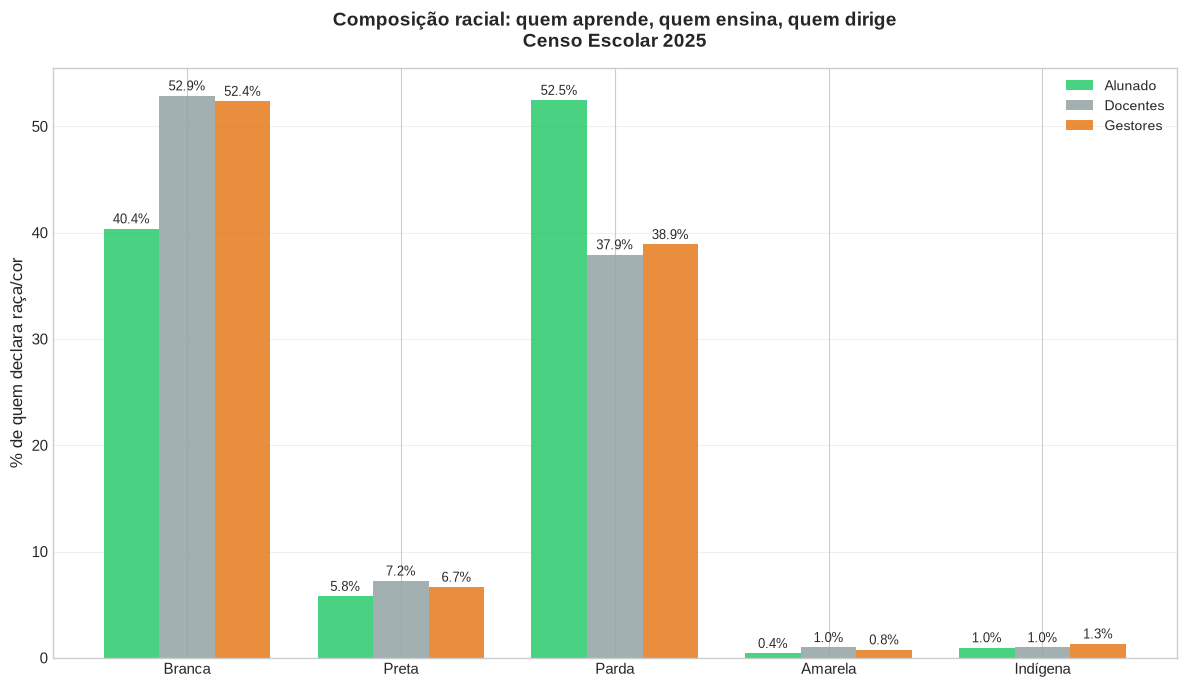

In [2]:
# Carregar composições raciais (scripts/analise_interseccional.py)
raca = pd.read_csv(OUTPUTS_PATH + 'interseccional_raca.csv')
rep = pd.read_csv(OUTPUTS_PATH + 'representatividade_racial.csv')

racas = ['Branca', 'Preta', 'Parda', 'Amarela', 'Indígena']
ordem_cat = ['Alunado', 'Docentes', 'Gestores']

print("📊 COMPOSIÇÃO RACIAL — % de quem declara raça/cor")
print("=" * 60)
print(raca[['categoria'] + racas].to_string(index=False))
print("\nRegistros 'não declarado' excluídos das porcentagens:")
for _, r in raca.iterrows():
    print(f"   • {r['categoria']}: {r['n_ND']:,.0f} ND de {r['n_declarado'] + r['n_ND']:,.0f} "
          f"({r['n_ND'] / (r['n_declarado'] + r['n_ND']) * 100:.1f}%)")

# --- Gráfico: composição racial nas três posições ---
raca_g = raca.set_index('categoria')[racas].T[ordem_cat]
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(racas)); w = 0.26
cores_cat = [CORES['neutro'], CORES['total'], CORES['feminino']]
for i, cat in enumerate(ordem_cat):
    bars = ax.bar(x + (i - 1) * w, raca_g := raca_g if False else raca_g, w) if False else None
bars_all = []
for i, cat in enumerate(ordem_cat):
    b = ax.bar(x + (i - 1) * w, raca_g[cat], w, label=cat, color=cores_cat[i], alpha=0.88)
    bars_all.append(b)
    for bar in b:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(racas)
ax.set_ylabel('% de quem declara raça/cor', fontsize=12)
ax.set_title('Composição racial: quem aprende, quem ensina, quem dirige\nCenso Escolar 2025',
             fontweight='bold', pad=15)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(GRAPHICS_PATH + '10_raca_alunado_docentes_gestores.png', dpi=300, bbox_inches='tight')
print("\n💾 Gráfico salvo: 10_raca_alunado_docentes_gestores.png")
plt.show()

### 📖 Leitura do filtro racial

- **Branca:** 40.4% do alunado → 52.9% da docência → 52.4% da gestão. Sobrepresentados
  desde a docência (+12.5 pp sobre o alunado) e estáveis até a gestão.
- **Parda:** maioria do alunado (52.5%), mas **minorias na docência (37.9%) e gestão (38.9%)** —
  o filtro mais forte do país está na **entrada na carreira**, não na promoção.
- **Preta:** 5.8% alunado → 7.2% docência → 6.7% gestão — sub-representados em todas as etapas.
- **Indígena:** 0.96% alunado → 0.97% docência → 1.32% gestão (n pequeno, interpretar com cautela).

**Razão de presença (gestão ÷ docência):** próxima de 1 para todas as raças (0.92–1.37) —
a gestão **espelha a raça da docência**, como espelha o gênero. O gargalo racial é
**quem entra no magistério**, não quem ascende a direção.


In [3]:
print("📈 RAZÃO DE PRESENÇA NA GESTÃO (gest ÷ doc; gest ÷ alunado)")
print("=" * 60)
print(rep.to_string(index=False))

print("\n💡 INTERPRETAÇÃO:")
print("   • gest_por_doc ≈ 1 para todas as raças: a gestão espelha a raça da docência.")
print("   • O desvio relevante é gest_por_alunado: brancos 1.30x, pardos 0.74x —")
print("     o filtro racial está na ENTRADA na docência, não na promoção à gestão.")

📈 RAZÃO DE PRESENÇA NA GESTÃO (gest ÷ doc; gest ÷ alunado)
    raca  gest_por_doc  gest_por_alunado
  Branca         0.990             1.297
   Preta         0.920             1.150
   Parda         1.025             0.741
 Amarela         0.771             1.799
Indígena         1.367             1.376

💡 INTERPRETAÇÃO:
   • gest_por_doc ≈ 1 para todas as raças: a gestão espelha a raça da docência.
   • O desvio relevante é gest_por_alunado: brancos 1.30x, pardos 0.74x —
     o filtro racial está na ENTRADA na docência, não na promoção à gestão.


## 3️⃣ Raça/cor por Rede de Ensino

Onde a docência é mais branca? Onde a gestão? Comparar doc_ e gest_ por rede.

In [4]:
por_rede = pd.read_csv(OUTPUTS_PATH + 'interseccional_raca_por_rede.csv')

print("🏫 COMPOSIÇÃO RACIAL POR REDE (doc_ = docentes, gest_ = gestores)")
print("=" * 60)
print(por_rede.to_string(index=False))

print("\n🔍 DESTAQUES:")
print("   • Rede Privada: docência 60.4% branca → gestão 65.5% branca (embranquece no topo).")
print("   • Rede Municipal (a maior do país): docência 47.7% branca, gestão 45.6% branca —")
print("     a rede mais negra e mais feminina do sistema.")
print("   • Rede Federal: docência 60.9% branca, gestão 62.8% branca, 3.4% indígena na gestão")
print("     estadual vs 0.2% na federal (n pequeno — cautela).")

🏫 COMPOSIÇÃO RACIAL POR REDE (doc_ = docentes, gest_ = gestores)
TP_DEPENDENCIA  doc_Branca (%)  doc_Preta (%)  doc_Parda (%)  doc_Amarela (%)  doc_Indígena (%)  gest_Branca (%)  gest_Preta (%)  gest_Parda (%)  gest_Amarela (%)  gest_Indígena (%)
      Estadual           56.43           7.18          33.80             0.90              1.68            58.12            6.06           31.57              0.88               3.37
       Federal           60.90           6.48          31.31             1.07              0.23            62.75            5.70           31.04              0.34               0.17
     Municipal           47.73           7.60          42.72             1.05              0.91            45.59            7.39           45.17              0.63               1.21
       Privada           60.44           6.45          32.07             0.93              0.10            65.52            5.23           28.19              1.00               0.05

🔍 DESTAQUES:
   • Rede P

## 4️⃣ IFR Municipal: Onde a Gestão Descola da Base

### 📌 A "carreira" município a município

IFR = % gestoras ÷ % docentes mulheres, calculado para os **5.571 municípios** com gestores
identificados. Extremos filtrados por `n_gestores ≥ 20` (estabilidade do índice).

In [5]:
mun = pd.read_csv(OUTPUTS_PATH + 'ifr_municipal.csv')

print(f"🗺️ IFR MUNICIPAL — {len(mun):,} municípios")
print("=" * 60)
print(f"   • IFR < 0.90  (gestão abaixo da base): {(mun['ifr'] < 0.90).sum():5d} municípios")
print(f"   • IFR 0.90–1.10 (proporcional):         {mun['ifr'].between(0.90, 1.10).sum():5d} municípios")
print(f"   • IFR > 1.10  (gestão acima da base):   {(mun['ifr'] > 1.10).sum():5d} municípios")
print(f"   • Gestoras < 50% (minorias absolutas):  {(mun['pct_gest_fem'] < 50).sum():5d} municípios")

filtro = mun[mun['n_gestores'] >= 20].copy()
menores = filtro.nsmallest(10, 'ifr')
maiores = filtro.nlargest(10, 'ifr')

print("\n📍 10 MENORES IFR (n_gestores ≥ 20) — onde a gestão descola da docência:")
print(menores[['NO_MUNICIPIO', 'SG_UF', 'pct_doc_fem', 'pct_gest_fem', 'ifr']].to_string(index=False))
print("\n📍 10 MAIORES IFR (n_gestores ≥ 20):")
print(maior_df := maiores[['NO_MUNICIPIO', 'SG_UF', 'pct_doc_fem', 'pct_gest_fem', 'ifr']])
print(maior_df.to_string(index=False))

🗺️ IFR MUNICIPAL — 5,571 municípios
   • IFR < 0.90  (gestão abaixo da base):  1080 municípios
   • IFR 0.90–1.10 (proporcional):          2205 municípios
   • IFR > 1.10  (gestão acima da base):    2286 municípios
   • Gestoras < 50% (minorias absolutas):    224 municípios

📍 10 MENORES IFR (n_gestores ≥ 20) — onde a gestão descola da docência:
             NO_MUNICIPIO SG_UF  pct_doc_fem  pct_gest_fem   ifr
                    Maraã    AM        63.08          6.86 0.109
                   Lábrea    AM        59.62          9.68 0.162
                    Feijó    AC        52.50          9.93 0.189
                 Ladainha    MG        74.33         14.29 0.192
                   Portel    PA        58.57         13.02 0.222
                   Pauini    AM        41.81          9.57 0.229
                   Japurá    AM        57.35         13.21 0.230
                    Jutaí    AM        55.64         12.90 0.232
                  Urucará    AM        56.35         13.89 0.246
Sã

### 📊 Distribuição municipal do IFR

💾 Gráfico salvo: 11_ifr_municipal.png


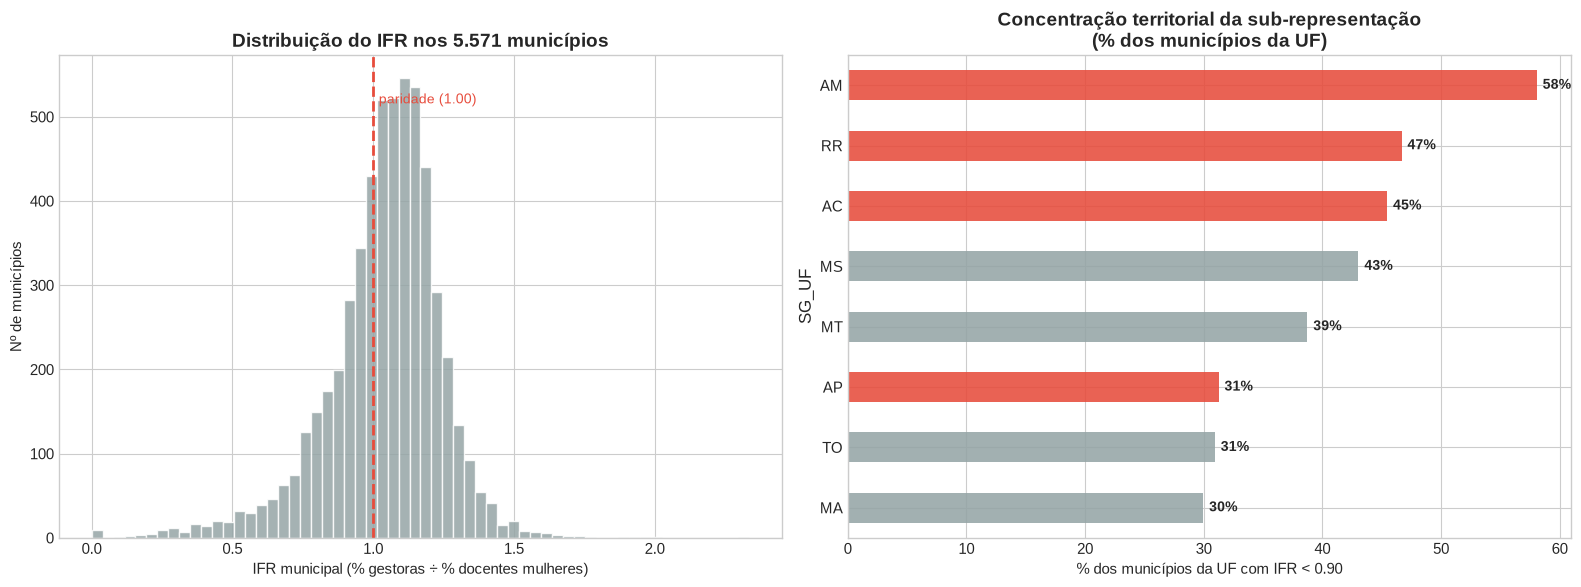


📍 UFs com maior % de municípios onde gestoras são MINORIA (<50%):
SG_UF
AM    54.8
AC    31.8
RR    20.0
AP    18.8
MT     9.2
PA     9.0
RO     7.7
MS     7.6


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma
ax = axes[0]
ax.hist(mun['ifr'], bins=60, color=CORES['total'], alpha=0.85, edgecolor='white')
ax.axvline(1.0, color=CORES['destaque'], linestyle='--', linewidth=2)
ax.text(1.02, ax.get_ylim()[1] * 0.9, 'paridade (1.00)', color=CORES['destaque'], fontsize=10)
ax.set_xlabel('IFR municipal (% gestoras ÷ % docentes mulheres)', fontsize=11)
ax.set_ylabel('Nº de municípios', fontsize=11)
ax.set_title('Distribuição do IFR nos 5.571 municípios', fontweight='bold')

# Concentração por UF: % dos municípios da UF com IFR<0.9 (top 8)
ax = axes[1]
pct_baixo = mun.groupby('SG_UF').apply(
    lambda g: (g['ifr'] < 0.90).mean() * 100, include_groups=False
).sort_values(ascending=False).head(8)
cores_bar = [CORES['destaque'] if uf in ('AM', 'AC', 'PA', 'RR', 'AP') else CORES['total'] for uf in pct_baixo.index]
pct_baixo.plot(kind='barh', ax=ax, color=cores_bar, alpha=0.88)
ax.invert_yaxis()
ax.set_xlabel('% dos municípios da UF com IFR < 0.90', fontsize=11)
ax.set_title('Concentração territorial da sub-representação\n(% dos municípios da UF)',
             fontweight='bold')
for i, (uf, v) in enumerate(pct_baixo.items()):
    ax.text(v + 0.5, i, f'{v:.0f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(GRAPHICS_PATH + '11_ifr_municipal.png', dpi=300, bbox_inches='tight')
print("💾 Gráfico salvo: 11_ifr_municipal.png")
plt.show()

# % de municípios com gestoras minoritárias, por UF
pct_menor50 = mun.groupby('SG_UF').apply(
    lambda g: (g['pct_gest_fem'] < 50).mean() * 100).sort_values(ascending=False)
print("\n📍 UFs com maior % de municípios onde gestoras são MINORIA (<50%):")
print(pct_menor50.head(8).round(1).to_string())

## ✅ Resumo do Notebook

### 📊 Análises Realizadas:
- ✅ Composição racial: alunado × docência × gestão
- ✅ Razão de presença racial na gestão (gest ÷ doc, gest ÷ alunado)
- ✅ Composição racial por rede de ensino
- ✅ IFR municipal: 5.571 municípios, extremos com filtro de n

### 📁 Gráficos Gerados:
- `10_raca_alunado_docentes_gestores.png`
- `11_ifr_municipal.png`

### 🔍 Insights Principais:
- **O filtro racial está na entrada da docência**: pardos são 52.5% do alunado mas 37.9%
  da docência; brancos 40.4% do alunado mas 52.9% da docência.
- **A gestão espelha a raça da docência** (razões 0.92–1.37) — mesmo padrão do gênero (IFR 1.05).
- **Rede Privada embranquece no topo** (docência 60.4% branca → gestão 65.5% branca);
  Municipal é a rede mais negra e mais feminina.
- **Sub-representação municipal concentrada no Norte/AM**: dos 1.080 municípios com
  IFR < 0.90, grande parte está na Amazônia Legal; Maraã (AM) tem IFR 0.11 —
  6.9% de gestoras numa docência de 63% mulheres.

### ⚠️ Limitações:
- Agregados não cruzam raça × gênero: impossível calcular "% de gestoras negras"
- IFR municipal instável em municípios pequenos (filtro n ≥ 20 nos extremos)
- 12–19% de não declarados em raça/cor variam entre as três tabelas

### 🚀 Próximos Passos:
P2 — funil por etapa (ecológico) e P3 — rigor estatístico (ICs com bases corretas).

---

✨ **Notebook 05 concluído!** ✨

**Desenvolvido com ❤️ por Sara**